In [1]:
# selectivenet threshold
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score,accuracy_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import os
import matplotlib.pyplot as plt
import scipy.stats as stats
import matplotlib.lines as mlines
import matplotlib.ticker as ticker

C:\Users\098986\AppData\Local\Temp\ipykernel_35212\835746354.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


# Classification


In [38]:
exp_dict = {
    '0':'Raw',
    #'1': '16 + l2: 0.05',
    #'2': '32 + l2: 0.05 + dropout: 0.5',
    '3': '64 + l2: 0.05',
    '4': '32 + l2: 0.05',
    #'5': '16 + l2: 0.05',
    #'6': '64 + l2: 0.1',
    '7': '64 + dropout: 0.5',
    '8': '64 + l2: 0.01',
    '9': '32 + l2: 0.01',
    #'10': '64 + l2: 0.05 + dropout: 0.5',
}
def plot_confidence_loss(folder, epochs, num_folds=5,specific_fold=None):
    """
    Function to plot training and validation loss with 95% confidence intervals across multiple folds.

    :param folder: Folder containing the metric files for all folds
    :param epochs: Number of epochs to plot
    :param num_folds: Number of validation folds
    """
    # Initialize lists to store data
    all_tr_loss = []
    all_val_loss = []
    all_val_auc = []
    all_f1_score = []
    # Load data for each fold
    for fold in range(0, num_folds ):
        if specific_fold is not None:
            fold = specific_fold

        fold_folder = os.path.join(folder, f'{fold}')
        tr_metric_path = os.path.join(fold_folder, 'train_metrics.csv')
        val_metric_path = os.path.join(fold_folder, 'vali_metrics.csv')
        print(tr_metric_path)

        tr_metric = pd.read_csv(tr_metric_path)
        val_metric = pd.read_csv(val_metric_path)
            
        # Skip duplicate rows for validation data: take every second row starting from the first
        val_metric = val_metric.iloc[1::2]
        tr_metric = tr_metric.iloc[1::2]

        # Ensure the data has the same length as epochs
        all_tr_loss.append(tr_metric['loss'][:epochs].values)
        all_val_loss.append(val_metric['loss'][:epochs].values)
        all_val_auc.append(val_metric['auc'][:epochs].values)
        all_f1_score.append(val_metric['f1'][:epochs].values)
    # Convert lists to numpy arrays for easier calculations
    all_tr_loss = np.array(all_tr_loss)
    all_val_loss = np.array(all_val_loss)
    all_val_auc = np.array(all_val_auc)
    all_f1_score = np.array(all_f1_score)

    # Calculate mean and 95% confidence interval for train and validation loss
    tr_loss_mean = np.mean(all_tr_loss, axis=0)
    tr_loss_ci = stats.sem(all_tr_loss, axis=0) * stats.t.ppf((1 + 0.95) / 2., num_folds-1)
    
    val_loss_mean = np.mean(all_val_loss, axis=0)
    val_loss_ci = stats.sem(all_val_loss, axis=0) * stats.t.ppf((1 + 0.95) / 2., num_folds-1)

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 8))
    epochs_range = range(1, epochs + 1)
    ax.plot(epochs_range, tr_loss_mean, label='Average Train Loss', color='tab:blue')
    ax.fill_between(epochs_range, tr_loss_mean - tr_loss_ci, tr_loss_mean + tr_loss_ci, color='tab:blue', alpha=0.2)

    ax.plot(epochs_range, val_loss_mean, label='Average Validation Loss', color='tab:orange')
    ax.fill_between(epochs_range, val_loss_mean - val_loss_ci, val_loss_mean + val_loss_ci, color='tab:orange', alpha=0.2)
    
    ax.plot(epochs_range, all_val_auc.mean(axis=0), label='Average Validation AUC', color='tab:red')
    ax.fill_between(epochs_range, all_val_auc.mean(axis=0) - all_val_auc.std(axis=0), all_val_auc.mean(axis=0) + all_val_auc.std(axis=0), color='tab:red', alpha=0.2)

    ax.plot(epochs_range, all_f1_score.mean(axis=0), label='Average Validation F1-score', color='tab:purple')
    ax.fill_between(epochs_range, all_f1_score.mean(axis=0) - all_f1_score.std(axis=0), all_f1_score.mean(axis=0) + all_f1_score.std(axis=0), color='tab:purple', alpha=0.2)

    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.set_title('Loss Plot')
    ax.legend()

    plt.show()




def get_average_auc_per_eppch(folder):
    """
    Function to get the average AUC per epoch across all folds.
    """
    # Initialize lists to store data
    all_val_auc = []
    # Load data for each fold
    for fold in range(0, 5):
        fold_folder = os.path.join(folder, f'{fold}')
        val_metric_path = os.path.join(fold_folder, 'vali_metrics.csv')

        val_metric = pd.read_csv(val_metric_path)

        # Skip duplicate rows for validation data: take every second row starting from the first
        val_metric = val_metric.iloc[1::2]

        # Ensure the data has the same length as epochs
        all_val_auc.append(val_metric['auc'].values)
    print(len(all_val_auc[1]))    
    # Convert lists to numpy arrays for easier calculations
    all_val_auc = np.array(all_val_auc)

    #store mean auc per epoch
    mean_auc_per_epoch = []
    for i in range(len(all_val_auc[0])):
        mean_auc_per_epoch.append(np.mean(all_val_auc[:,i]))


    return mean_auc_per_epoch

## early stopping
# Implementing early stopping mechanism based on validation loss
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, current_loss):
        if self.best_loss is None:
            self.best_loss = current_loss
        elif current_loss < self.best_loss - self.min_delta:
            self.best_loss = current_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def reset(self):
        self.best_loss = None
        self.counter = 0
        self.early_stop = False

def early_stopping_epoch(folder,patience,min_delta):
    epoch_lst = []
    for fold, _ in enumerate(range(5)):
        vali_loss = pd.read_csv(os.path.join(folder, str(fold), "vali_metrics.csv")).loc[0::2,]["loss"].tolist()
        early_stop = EarlyStopping(patience, min_delta)
        
        for epoch, loss in enumerate(vali_loss):
            early_stop(loss)
            if early_stop.early_stop:
                epoch_lst.append(epoch + 1)  # Epochs are usually 1-indexed
                break
        else:
            epoch_lst.append(len(vali_loss))  # If no early stop, append the total number of epochs
    
    return epoch_lst


def calculate_auc_early_stopping(epoch_lst):

    auc_lst = []
    for fold, _ in enumerate(range(5)):
        vali_auc = pd.read_csv(os.path.join(folder, str(fold), "vali_metrics.csv")).loc[0::2,]["auc"].tolist()
        auc_lst.append(vali_auc[epoch_lst[fold]-1])

    
    return auc_lst

def calculate_auc_early_stopping_confidence(auc_lst):

    # Calculate confidence interval
    print(auc_lst)
    auc_mean = sum(auc_lst) / len(auc_lst)
    auc_std = (sum([(auc - auc_mean)**2 for auc in auc_lst]) / len(auc_lst))**0.5
    auc_confidence = 1.96 * auc_std / len(auc_lst)**0.5

    return auc_mean, auc_confidence
# Load validation loss data from CSV


../Output/Resnet10/Cluster/Resnet10_Final_plus_5_9/0\train_metrics.csv
../Output/Resnet10/Cluster/Resnet10_Final_plus_5_9/1\train_metrics.csv
../Output/Resnet10/Cluster/Resnet10_Final_plus_5_9/2\train_metrics.csv
../Output/Resnet10/Cluster/Resnet10_Final_plus_5_9/3\train_metrics.csv
../Output/Resnet10/Cluster/Resnet10_Final_plus_5_9/4\train_metrics.csv


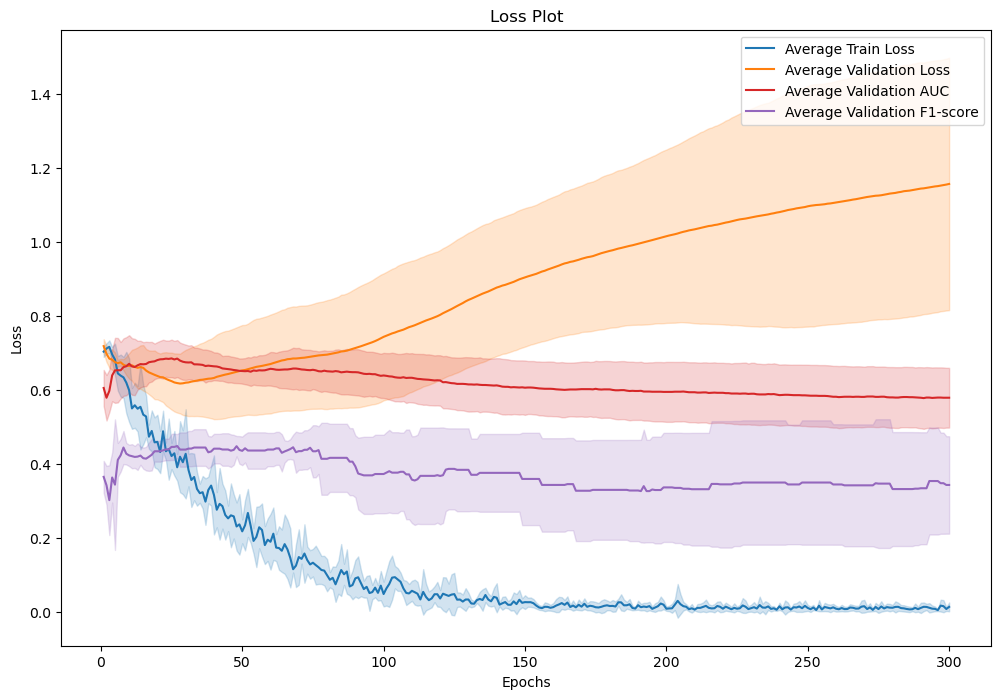

In [63]:
folder = '../Output/Resnet10/Cluster/Resnet10_Final_plus_5_9/'
plot_confidence_loss(folder,300)

In [ ]:
folder_prefix =  '../Output/Resnet10/Cluster/'
folder_suffix = 'Resnet10_Final_plus_5_'
plot_confidence_loss(folder,300)
auc_mean_per_epoch_dict = {str(i):None for i in range(9)}
for i in range(11):
    folder = folder_prefix +  folder_suffix + str(i) + '/'
    auc_mean_per_epoch_dict[str(i)] = get_average_auc_per_eppch(folder)



# 绘制每个实验的AUC均值曲线
def plot_auc_mean_per_epoch(auc_mean_per_epoch_dict, exp_dict, epochs=300):
    plt.figure(figsize=(12, 8))
    epochs_range = range(1, epochs + 1)
    
    for key, auc_means in auc_mean_per_epoch_dict.items():
        if key in exp_dict:
            label = exp_dict[key]
            plt.plot(epochs_range, auc_means, label=label)
    
    plt.xlabel('Epochs')
    plt.ylabel('Average AUC')
    plt.title('Average AUC per Epoch for Different Experiments')
    plt.legend()
    plt.show()

# 调用绘图函数
plot_auc_mean_per_epoch(auc_mean_per_epoch_dict, exp_dict)

## Swin-TS


../Output/Resnet10/Cluster/Swin_TS_plus_5_1/0\train_metrics.csv
../Output/Resnet10/Cluster/Swin_TS_plus_5_1/1\train_metrics.csv
../Output/Resnet10/Cluster/Swin_TS_plus_5_1/2\train_metrics.csv
../Output/Resnet10/Cluster/Swin_TS_plus_5_1/3\train_metrics.csv
../Output/Resnet10/Cluster/Swin_TS_plus_5_1/4\train_metrics.csv


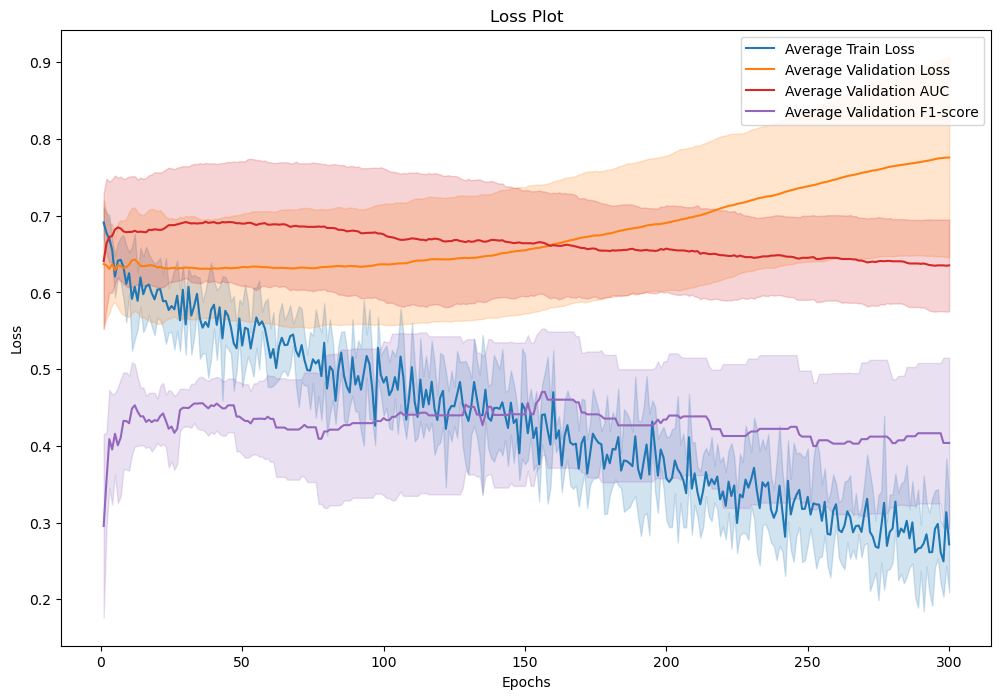

../Output/Resnet10/Cluster/Swin_TS_plus_5_0/
300
../Output/Resnet10/Cluster/Swin_TS_plus_5_1/
300


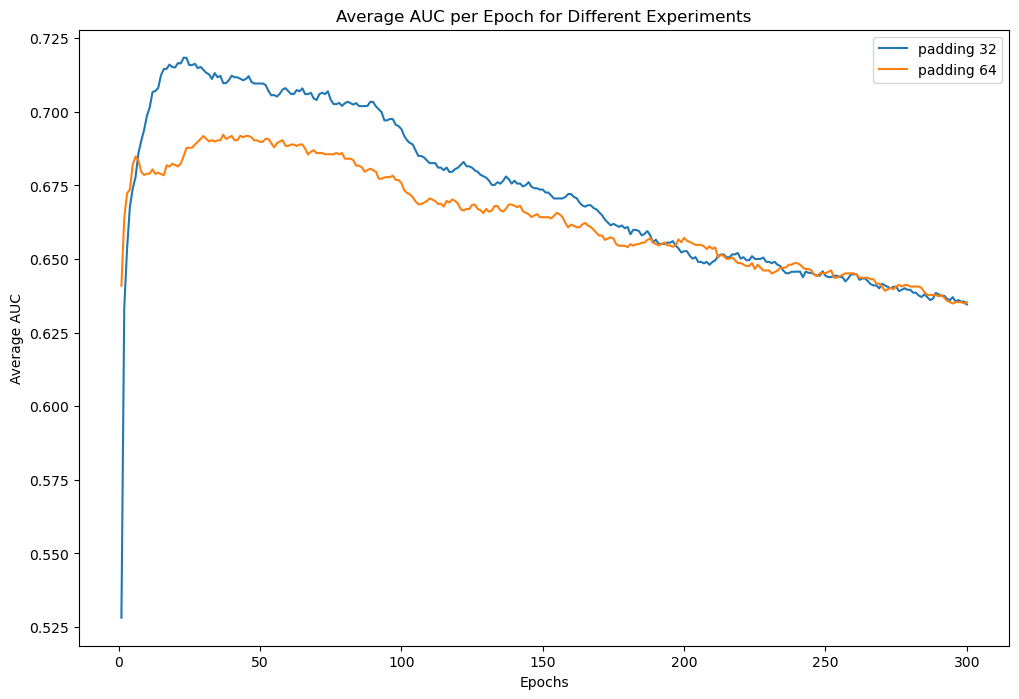

In [133]:
folder_prefix =  '../Output/Resnet10/Cluster/'
folder_suffix = 'Swin_TS_plus_5_'
exp_dict = {'0': 'padding 32', '1': 'padding 64'}
folder = folder_prefix +  folder_suffix + '1/'
plot_confidence_loss(folder,300)
auc_mean_per_epoch_dict = {str(i):None for i in range(2)}
for i in range(2):
    folder = folder_prefix +  folder_suffix + str(i) + '/'
    print(folder)
    auc_mean_per_epoch_dict[str(i)] = get_average_auc_per_eppch(folder)



# 绘制每个实验的AUC均值曲线
def plot_auc_mean_per_epoch(auc_mean_per_epoch_dict, exp_dict, epochs=300):
    plt.figure(figsize=(12, 8))
    epochs_range = range(1, epochs + 1)
    
    for key, auc_means in auc_mean_per_epoch_dict.items():
        if key in exp_dict:
            label = exp_dict[key]
            plt.plot(epochs_range, auc_means, label=label)
    
    plt.xlabel('Epochs')
    plt.ylabel('Average AUC')
    plt.title('Average AUC per Epoch for Different Experiments')
    plt.legend()
    plt.show()

# 调用绘图函数
plot_auc_mean_per_epoch(auc_mean_per_epoch_dict, exp_dict)


## Early stopping


In [31]:
folder_lst_resnet10 = ['../Output/Resnet10/Cluster/Resnet10_Final_plus_5_0/','../Output/Resnet10/Cluster/Resnet10_Final_plus_5_3/','../Output/Resnet10/Cluster/Resnet10_Final_plus_5_4/','../Output/Resnet10/Cluster/Resnet10_Final_plus_5_7/','../Output/Resnet10/Cluster/Resnet10_Final_plus_5_8/','../Output/Resnet10/Cluster/Resnet10_Final_plus_5_9/']
early_stopping_auc_dict = {folder:None for folder in folder_lst}

for folder in folder_lst_resnet10:
    early_stopping_epochs = early_stopping_epoch(folder,30,0.005)
    early_stopping_aucs = calculate_auc_early_stopping(early_stopping_epochs)
    early_stopping_mean_auc = calculate_auc_early_stopping_confidence(early_stopping_aucs)
    early_stopping_auc_dict[folder] = early_stopping_mean_auc


folder_lst_sw = ['../Output/Resnet10/Cluster/Swin_TS_plus_5_0/','../Output/Resnet10/Cluster/Swin_TS_plus_5_1/']
early_stopping_auc_dict = {folder:None for folder in folder_lst_sw}
for folder in folder_lst_sw:
    early_stopping_epochs = early_stopping_epoch(folder,500,0.005)
    early_stopping_aucs = calculate_auc_early_stopping(early_stopping_epochs)
    early_stopping_mean_auc = calculate_auc_early_stopping_confidence(early_stopping_aucs)
    early_stopping_auc_dict[folder] = early_stopping_mean_auc


print(early_stopping_auc_dict)


NameError: name 'folder_lst' is not defined

# confidence score

In [48]:
from sklearn.metrics import accuracy_score,balanced_accuracy_score
epoch = 299
fold = 4
y_pred = np.load(f'../Output/Resnet10/Cluster/Swin_TS_plus_5_1/{fold}/y_pred.npy')
y_pred_label = np.argmax(y_pred, axis=2)
y_true_df = pd.read_csv(f'../Data/Test/Final_DataSet/Labels/lg_mixed_extended+5_folds/val_cv_{fold}.csv')
y_true = y_true_df['HGP_Type'].values.tolist()
accuracy_score(y_true,y_pred_label[epoch]),balanced_accuracy_score(y_true,y_pred_label[epoch])




(0.6938775510204082, 0.6961538461538461)

Accuracy: 0.6938775510204082
Balanced Accuracy: 0.6961538461538461


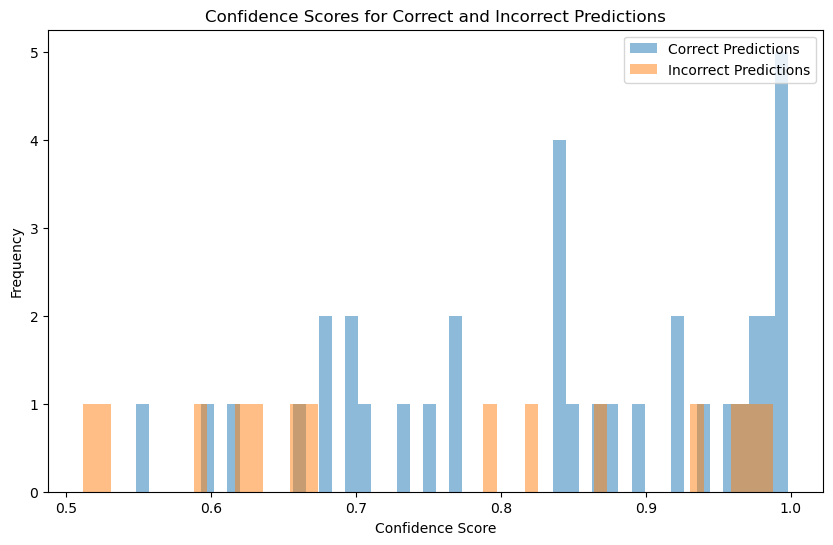

In [49]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Load predictions and true labels
y_pred = np.load(f'../Output/Resnet10/Cluster/Swin_TS_plus_5_1/{fold}/y_pred.npy')
y_pred_label = np.argmax(y_pred, axis=2)
y_true_df = pd.read_csv(f'../Data/Test/Final_DataSet/Labels/lg_mixed_extended+5_folds/val_cv_{fold}.csv')
y_true = y_true_df['HGP_Type'].values.tolist()
# Calculate accuracy and balanced accuracy
accuracy = accuracy_score(y_true, y_pred_label[epoch])
balanced_accuracy = balanced_accuracy_score(y_true, y_pred_label[epoch])
print(f'Accuracy: {accuracy}')
print(f'Balanced Accuracy: {balanced_accuracy}')

# Since y_pred is already softmaxed, we can directly use it as confidence scores
confidence_max = np.max(y_pred, axis=2)

# Determine correct and incorrect predictions
correct_predictions = (y_pred_label[100] == y_true)
incorrect_predictions = ~correct_predictions

# Plot confidence scores for correct and incorrect predictions
plt.figure(figsize=(10, 6))
plt.hist(confidence_max[epoch][correct_predictions], bins=50, alpha=0.5, label='Correct Predictions')
plt.hist(confidence_max[epoch][incorrect_predictions], bins=50, alpha=0.5, label='Incorrect Predictions')
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.title('Confidence Scores for Correct and Incorrect Predictions')
plt.show()


## Selective analysis of the data


In [6]:
a = 'CILM_122_0'
a[:-2]

'CILM_122'

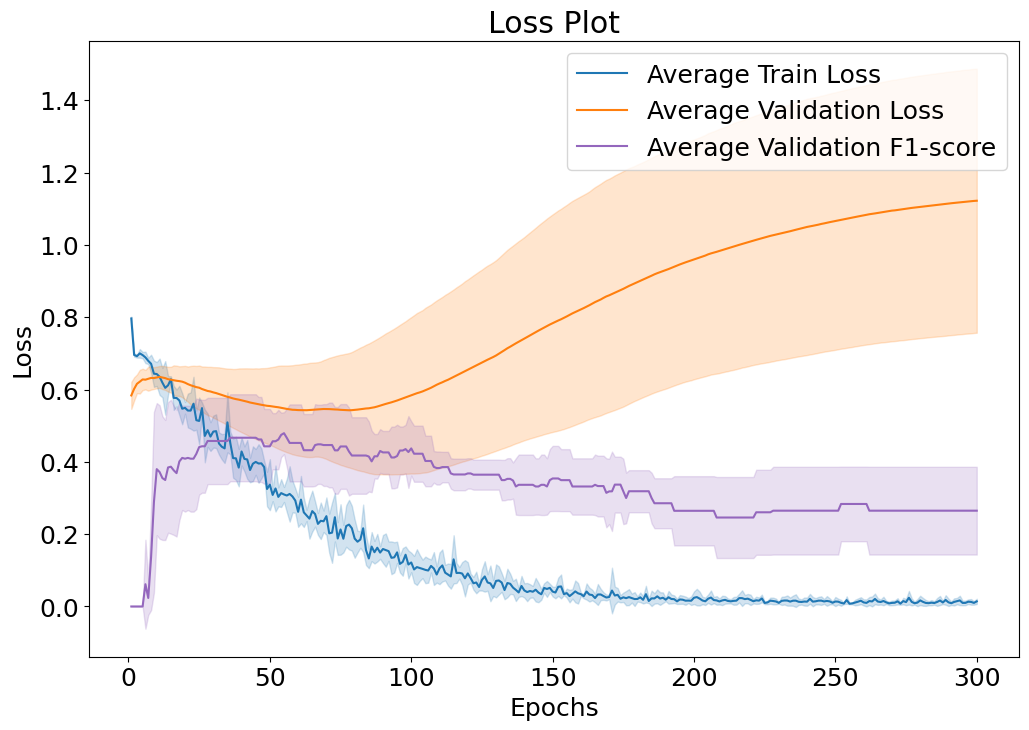

In [71]:
#sort by coverage
# selectivenet threshold
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score,accuracy_score,balanced_accuracy_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import os
import matplotlib.pyplot as plt
import scipy.stats as stats
import matplotlib.lines as mlines
import matplotlib.ticker as ticker

#return sorted output,predictions,true_labels
def check_correct_select(model_output, model_selection, true_label, cov_rate=0.4, epoch=100):
    # get selection head output
    selection = model_selection[epoch,]
    index = np.argsort(selection[:,0])

    selection = selection[index]
    # get the main head output
    output = model_output[epoch,:,:]

    predictions = np.argmax(output, axis=1)
    coverage_rate = int(round(len(selection)) * (1-cov_rate))
    true_label = true_label[epoch,:]
    # sorted by the reservation
    # if coverage_rate is larger than the length of the reservation
    if coverage_rate >= len(selection):
        coverage_rate -= 1
    output = output[index,:][coverage_rate:]
    predictions = predictions[index][coverage_rate:]
    true_labels = true_label[index][coverage_rate:]
    # print(true_labels)
    selection = selection[coverage_rate:]
    
    # cat with reservation
    output = np.concatenate((output, selection), axis=1)
    # reverse the order of all returned arrays
    print(selection)
    return output[::-1], predictions[::-1], true_labels[::-1], selection[::-1]
    
    
def plot_confidence_loss(folder, epochs, num_folds=5,specific_fold=None):
    """
    Function to plot training and validation loss with 95% confidence intervals across multiple folds.

    :param folder: Folder containing the metric files for all folds
    :param epochs: Number of epochs to plot
    :param num_folds: Number of validation folds
    """
    # Initialize lists to store data
    all_tr_loss = []
    all_val_loss = []
    all_val_auc = []
    all_f1_score = []
    # Load data for each fold
    for fold in range(0, num_folds ):
        if specific_fold is not None:
            fold = specific_fold

        fold_folder = os.path.join(folder, f'{fold}')
        tr_metric_path = os.path.join(fold_folder, 'train_metrics.csv')
        val_metric_path = os.path.join(fold_folder, 'vali_metrics.csv')

        tr_metric = pd.read_csv(tr_metric_path)
        val_metric = pd.read_csv(val_metric_path)

        # Skip duplicate rows for validation data: take every second row starting from the first
        val_metric = val_metric.iloc[1::2]
        tr_metric = tr_metric.iloc[1::2]

        # Ensure the data has the same length as epochs
        all_tr_loss.append(tr_metric['loss'][:epochs].values)
        all_val_loss.append(val_metric['loss'][:epochs].values)
        all_val_auc.append(val_metric['auc'][:epochs].values)
        all_f1_score.append(val_metric['f1'][:epochs].values)
    # Convert lists to numpy arrays for easier calculations
    all_tr_loss = np.array(all_tr_loss)
    all_val_loss = np.array(all_val_loss)
    all_val_auc = np.array(all_val_auc)
    all_f1_score = np.array(all_f1_score)

    # Calculate mean and 95% confidence interval for train and validation loss
    tr_loss_mean = np.mean(all_tr_loss, axis=0)
    tr_loss_ci = stats.sem(all_tr_loss, axis=0) * stats.t.ppf((1 + 0.95) / 2., num_folds-1)
    
    val_loss_mean = np.mean(all_val_loss, axis=0)
    val_loss_ci = stats.sem(all_val_loss, axis=0) * stats.t.ppf((1 + 0.95) / 2., num_folds-1)

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 8))
    epochs_range = range(1, epochs + 1)
    ax.plot(epochs_range, tr_loss_mean, label='Average Train Loss', color='tab:blue')
    ax.fill_between(epochs_range, tr_loss_mean - tr_loss_ci, tr_loss_mean + tr_loss_ci, color='tab:blue', alpha=0.2)

    ax.plot(epochs_range, val_loss_mean, label='Average Validation Loss', color='tab:orange')
    ax.fill_between(epochs_range, val_loss_mean - val_loss_ci, val_loss_mean + val_loss_ci, color='tab:orange', alpha=0.2)
    
    #ax.plot(epochs_range, all_val_auc.mean(axis=0), label='Average Validation AUC', color='tab:red')
    #ax.fill_between(epochs_range, all_val_auc.mean(axis=0) - all_val_auc.std(axis=0), all_val_auc.mean(axis=0) + all_val_auc.std(axis=0), color='tab:red', alpha=0.2)

    ax.plot(epochs_range, all_f1_score.mean(axis=0), label='Average Validation F1-score', color='tab:purple')
    ax.fill_between(epochs_range, all_f1_score.mean(axis=0) - all_f1_score.std(axis=0), all_f1_score.mean(axis=0) + all_f1_score.std(axis=0), color='tab:purple', alpha=0.2)

    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.set_title('Loss Plot')
    ax.legend()

    plt.show()


def plot_loss(folder, fold,epochs):
    """
    Function to plot training and validation loss for a specific fold.

    :param folder: Folder containing the metric files
    :param fold: Specific fold number
    """
    plt.rcParams['font.size'] = 18
    fold_folder = os.path.join(folder, str(fold))
    tr_metric_path = os.path.join(fold_folder, 'train_metrics.csv')
    val_metric_path = os.path.join(fold_folder, 'vali_metrics.csv')
    
    tr_metric = pd.read_csv(tr_metric_path)
    val_metric = pd.read_csv(val_metric_path)
    
    fig, ax1 = plt.subplots(figsize=(12, 8))

    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')

    ax1.plot(range(epochs), tr_metric['loss'].unique(), label='Train Loss', color='tab:blue')
    ax1.plot(range(epochs), val_metric['loss'].unique(), label='Val Loss', color='tab:orange')
    auc_value_lst = [tr_metric.apply(lambda x: x['auc'][1:-1],axis=1)][0]
    auc_value_lst = [float(auc_value_lst[i]) for i in range(0,300,2)]
    ax1.plot(range(epochs), auc_value_lst, label='Train_AUC', color='tab:red')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.set_ylabel('L2 Loss')
    tr_metric_l2_loss = tr_metric.loc[0::2, 'l2_loss']
    ax2.plot(range(epochs), tr_metric_l2_loss, label='Train L2 Loss', color='tab:green')

    ax2.legend(loc='upper right')

    # Setting the y-axis limits for ax2
    ax2.set_ylim(0, 180)
    
    # Adding custom tick marks for the right y-axis
    major_ticks = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180]
    minor_ticks = [0,20,40,60,80,100,120,140,160,180]
    ax2.yaxis.set_major_locator(ticker.FixedLocator(major_ticks))
    ax2.yaxis.set_minor_locator(ticker.FixedLocator(minor_ticks))
    ax2.yaxis.set_major_formatter(ticker.ScalarFormatter())
    
    # Adding zoomed-in plot
    inset_ax = fig.add_axes([0.1, -0.4, 0.8, 0.3])  # Position: [left, bottom, width, height]
    inset_ax.plot(range(300, epochs), tr_metric['l2_loss'].unique()[300:], color='tab:green')
    inset_ax.set_xlim(300, 800)  # Zoomed-in range
    inset_ax.set_ylim(0, 2)    # Zoomed-in range for L2 Loss
    inset_ax.set_title('Zoomed-in L2 Loss')
    inset_ax.grid(True)

    fig.tight_layout()
    ax1.title.set_text(f'Loss Plot')
    plt.show()
# Example usage



def auc_max_fold(folder, fold):
    """
    Function to find the epoch with the maximum AUC for different coverage rates for a specific fold.

    :param folder: Folder containing folds with data
    :param fold: Specific fold number
    :param npy_filename: Name of the .npy file containing predictions
    """
    coverage_rates = [i/10 for i in range(3, 11)]
    max_aucs = []
    max_epochs = []
    fold_folder = os.path.join(folder, str(fold))
    y_pred_path = os.path.join(fold_folder, 'y_pred.npy')
    y_selection_path = os.path.join(fold_folder, 'y_selection.npy')
    y_true_path = os.path.join(fold_folder, 'y_true.npy')

    y_pred = np.load(y_pred_path)
    y_selection = np.load(y_selection_path)
    y_true = np.load(y_true_path)

    for cov_rate in coverage_rates:
        max_auc = 0
        max_epoch = 0
        for epoch in range(y_pred.shape[0]):
            output, predictions, true_labels, selection = check_correct_select(y_pred, y_selection, y_true,cov_rate,epoch)
            try:
                auc = roc_auc_score(true_labels, output[:,1])
            except Exception as e:
                print(e)
                auc = 0

            if auc > max_auc:
                max_auc = auc
                max_epoch = epoch

        max_aucs.append(max_auc)
        max_epochs.append(max_epoch)

    return max_aucs, max_epochs

def auc_max_fold_train(folder, fold):
    """
    Function to find the epoch with the maximum AUC for different coverage rates for a specific fold.

    :param folder: Folder containing folds with data
    :param fold: Specific fold number
    :param npy_filename: Name of the .npy file containing predictions
    """
    coverage_rates = [i/10 for i in range(3, 11)]
    max_aucs = []
    max_epochs = []
    fold_folder = os.path.join(folder, str(fold))
    y_pred_path = os.path.join(fold_folder, 'y_pred_tr.npy')
    y_selection_path = os.path.join(fold_folder, 'y_selection_tr.npy')
    y_true_path = os.path.join(fold_folder, 'y_true_tr.npy')

    y_pred = np.load(y_pred_path)
    y_selection = np.load(y_selection_path)
    y_true = np.load(y_true_path)

    for cov_rate in coverage_rates:
        max_auc = 0
        max_epoch = 0
        for epoch in range(y_pred.shape[0]):
            output, predictions, true_labels, selection = check_correct_select(y_pred, y_selection, y_true,cov_rate,epoch)
            try:
                auc = roc_auc_score(true_labels, output[:,1])
            except Exception as e:
                print(e)
                auc = 0

            if auc > max_auc:
                max_auc = auc
                max_epoch = epoch

        max_aucs.append(max_auc)
        max_epochs.append(max_epoch)

    return max_aucs, max_epochs
def auc_max_all_folds(folder):
    """
    Function to find the epoch with the maximum AUC for different coverage rates for all folds.

    :param folder: Folder containing folds with data
    :param npy_filename: Name of the .npy file containing predictions
    """
    coverage_rates = [i/10 for i in range(3, 11)]
    all_aucs = {fold: {cov_rate: [] for cov_rate in coverage_rates} for fold in range(5)}
    all_epochs = {fold: {cov_rate: [] for cov_rate in coverage_rates} for fold in range(5)}
    for fold in range(5):
        y_true = pd.read_csv(f'../Data/Mixed_HGP/True_Label/largest_tm_lv_+5_mask/val_cv_{fold}.csv').HGP_Type.values
        #y_true = pd.read_csv(f'../../Data/Mixed_HGP/True_Label/Per_tumor_by_group_quantile_025//val_cv_{fold}.csv').HGP_Type.values
        fold_aucs, fold_epochs = auc_max_fold(folder, fold)
        for cov_rate, auc, epoch in zip(coverage_rates, fold_aucs, fold_epochs):
            all_aucs[fold][cov_rate].append(auc)
            all_epochs[fold][cov_rate].append(epoch)

    return all_aucs, all_epochs


def auc_max_all_folds_train(folder):
    """
    Function to find the epoch with the maximum AUC for different coverage rates for all folds.

    :param folder: Folder containing folds with data
    :param npy_filename: Name of the .npy file containing predictions
    """
    coverage_rates = [i/10 for i in range(3, 11)]
    all_aucs = {fold: {cov_rate: [] for cov_rate in coverage_rates} for fold in range(5)}
    all_epochs = {fold: {cov_rate: [] for cov_rate in coverage_rates} for fold in range(5)}
    for fold in range(5):
        #y_true = pd.read_csv(f'../../Data/Mixed_HGP/True_Label/Per_tumor_by_group_quantile_025//val_cv_{fold}.csv').HGP_Type.values
        fold_aucs, fold_epochs = auc_max_fold_train(folder, fold)
        for cov_rate, auc, epoch in zip(coverage_rates, fold_aucs, fold_epochs):
            all_aucs[fold][cov_rate].append(auc)
            all_epochs[fold][cov_rate].append(epoch)

    return all_aucs, all_epochs

def find_best_epoch(folder):
    best_epochs = []

    for fold in range(5):
        fold_folder = os.path.join(folder, str(fold))
        val_metric_path = os.path.join(fold_folder, 'vali_metrics.csv')
        val_metric = pd.read_csv(val_metric_path)
        best_epoch = val_metric.loc[val_metric['loss'].idxmin()].epoch
        best_epochs.append(best_epoch)
    return best_epochs
def plot_auc_vs_coverage_fold(folder, fold, epoch):
    
    coverage_rates = [i/10 for i in range(5, 11)]
    aucs = []

    fold_folder = os.path.join(folder, str(fold))
    y_pred_path = os.path.join(fold_folder, 'y_pred.npy')
    y_selection_path = os.path.join(fold_folder, 'y_selection.npy')
    y_true_path = os.path.join(fold_folder, 'y_true.npy')

    y_pred = np.load(y_pred_path)
    y_selection = np.load(y_selection_path)
    y_true = np.load(y_true_path)

    for cov_rate in coverage_rates:

        output, predictions, true_labels, selection = check_correct_select(y_pred, y_selection, y_true,cov_rate,epoch)
        try:
            auc = roc_auc_score(true_labels, output[:,1])
        except:
            auc = 0
        aucs.append(auc)

        # 绘制覆盖率与 AUC 的关系图
    plt.plot(coverage_rates, aucs, marker='o')
    plt.xlabel('Coverage Rate')
    plt.ylabel('AUC')
    #plt.title(f'AUC vs Coverage Rate for fold {fold} at epoch {epoch}')
    plt.title(f'AUC vs Coverage Rate ')
    plt.grid(True)
    plt.show()

def plot_accuracy_vs_coverage_fold(folder, fold, epoch):
    
    coverage_rates = [i/10 for i in range(5, 11)]
    accuracies = []

    fold_folder = os.path.join(folder, str(fold))
    y_pred_path = os.path.join(fold_folder, 'y_pred.npy')
    y_selection_path = os.path.join(fold_folder, 'y_selection.npy')
    y_true_path = os.path.join(fold_folder, 'y_true.npy')

    y_pred = np.load(y_pred_path)
    y_selection = np.load(y_selection_path)
    y_true = np.load(y_true_path)

    for cov_rate in coverage_rates:

        output, predictions, true_labels, selection = check_correct_select(y_pred, y_selection, y_true, cov_rate, epoch)
        # 使用 accuracy_score 而不是 roc_auc_score
        accuracy = accuracy_score(true_labels, predictions)
        accuracies.append(accuracy)

    # 绘制覆盖率与准确率的关系图
    plt.plot(coverage_rates, accuracies, marker='o')
    plt.xlabel('Coverage Rate')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy vs Coverage Rate')
    plt.grid(True)
    plt.show()

def plot_balanced_accuracy_vs_coverage_fold(folder, fold, epoch):
    
    coverage_rates = [i/10 for i in range(5, 11)]
    balanced_accuracies = []

    fold_folder = os.path.join(folder, str(fold))
    y_pred_path = os.path.join(fold_folder, 'y_pred.npy')
    y_selection_path = os.path.join(fold_folder, 'y_selection.npy')
    y_true_path = os.path.join(fold_folder, 'y_true.npy')

    y_pred = np.load(y_pred_path)
    y_selection = np.load(y_selection_path)
    y_true = np.load(y_true_path)

    for cov_rate in coverage_rates:

        output, predictions, true_labels, selection = check_correct_select(y_pred, y_selection, y_true, cov_rate, epoch)
        # 使用 balanced_accuracy_score 而不是 accuracy_score
        balanced_accuracy = balanced_accuracy_score(true_labels, predictions)
        balanced_accuracies.append(balanced_accuracy)

    # 绘制覆盖率与平衡准确率的关系图
    plt.plot(coverage_rates, balanced_accuracies, marker='o')
    plt.xlabel('Coverage Rate')
    plt.ylabel('Balanced Accuracy')
    plt.title(f'Balanced Accuracy vs Coverage Rate')
    plt.grid(True)
    plt.show()  
      
def plot_auc_vs_coverage_fold_train(folder, fold, epoch):
    
    coverage_rates = [i/10 for i in range(3, 11)]
    aucs = []

    fold_folder = os.path.join(folder, str(fold))
    y_pred_path = os.path.join(fold_folder, 'y_pred_tr.npy')
    y_selection_path = os.path.join(fold_folder, 'y_selection_tr.npy')
    y_true_path = os.path.join(fold_folder, 'y_true_tr.npy')

    y_pred = np.load(y_pred_path)
    y_selection = np.load(y_selection_path)
    y_true = np.load(y_true_path)

    for cov_rate in coverage_rates:

        output, predictions, true_labels, selection = check_correct_select(y_pred, y_selection, y_true,cov_rate,epoch)
        try:
            auc = roc_auc_score(true_labels, output[:,1])
        except:
            auc = 0
        aucs.append(auc)

        # 绘制覆盖率与 AUC 的关系图
    plt.plot(coverage_rates, aucs, marker='o')
    plt.xlabel('Coverage Rate')
    plt.ylabel('AUC')
    #plt.title(f'AUC vs Coverage Rate for fold {fold} at epoch {epoch}')
    plt.title(f'AUC vs Coverage Rate ')
    plt.grid(True)
    plt.show()
def plot_auc_vs_coverage(all_aucs):
    coverage_rates = [i/10 for i in range(5, 11)]

    fig, axs = plt.subplots(figsize=(20, 10))

    for rate in coverage_rates:
        axs.plot([rate]*5, [all_aucs[fold][rate] for fold in range(5)], 'o')

    mean_auc = [np.mean([all_aucs[fold][rate] for fold in range(5)]) for rate in coverage_rates]
    std_error_auc = [stats.sem([all_aucs[fold][rate] for fold in range(5)]) for rate in coverage_rates]
    std_error_auc = [float(x) for x in std_error_auc]#converting numpy float to python float

    axs.plot(coverage_rates, mean_auc, 'o-', color='green', label='Mean AUC')
    axs.fill_between(coverage_rates, np.array(mean_auc) - 2*np.array(std_error_auc), np.array(mean_auc) + 2*np.array(std_error_auc), color='green', alpha=0.2)
    axs.set_title('AUC vs Coverage Rate', fontsize=20)
    axs.set_xlabel('Coverage Rate', fontsize=25)  # Increase fontsize here
    axs.set_ylabel('AUC', fontsize=25)  # Increase fontsize here
    axs.tick_params(axis='both', which='major', labelsize=20)  # Increase tick fontsize here

    axs.legend(fontsize=20)

    plt.tight_layout()
    plt.show()
def min_max_scale(data, new_min=0, new_max=10000):
    min_val = np.min(data)
    max_val = np.max(data)
    scaled_data = (data - min_val) / (max_val - min_val) * (new_max - new_min) + new_min
    return scaled_data

# 应用最小-最大标准化到tumor_size
def Selection_pattern_plot(folder, fold, epoch):
    
    fold_folder = os.path.join(folder, str(fold))
    y_pred_path = os.path.join(fold_folder, 'y_pred.npy')
    y_selection_path = os.path.join(fold_folder, 'y_selection.npy')
    y_true_path = os.path.join(fold_folder, 'y_true.npy')

    y_pred = np.load(y_pred_path)
    y_selection = np.load(y_selection_path)
    y_true = np.load(y_true_path)

    y_true_df = pd.read_csv(f'../Data/Mixed_HGP/True_Label/largest_tm_lv_+5_mask/val_cv_{fold}.csv')
    # y_true_df = pd.read_csv(f'../../Data/Mixed_HGP/True_Label/Per_tumor_by_group_quantile_025/val_cv_{fold}.csv')
    index = np.argsort(y_selection[epoch,:,0].reshape(-1))
    # print(y_true_df.iloc[20,:])
    y_true_df = y_true_df.loc[index,].reset_index(drop=True)
    # 重置索引
    y_true_df.reset_index(drop=True, inplace=True)
    # print(y_true_df)

    # Create a boolean mask to filter rows where one of the columns has a value of 100
    # mask = (y_true_df['pHGP'] == 100) | (y_true_df['dHGP'] == 100) | (y_true_df['rHGP'] == 100)
    mask = (y_true_df['dHGP'] == 100) | (y_true_df['rHGP'] == 100)

    # Apply the mask to the DataFrame to get the filtered rows
    filtered_df = y_true_df[mask]

    # Print the filtered DataFrame
    y_true_df['rank'] = y_true_df.index[::-1]  # 反转索引，并使排名从1开始
    print(y_true_df)
    y_true_df['scaled_tumor_size'] = min_max_scale(y_true_df['tumor_size'])
    # 设置图形大小
    plt.figure(figsize=(12, 8))
    print(y_true_df['rank'].shape)
    print(y_true_df['dHGP'].shape)
    print(y_true_df['scaled_tumor_size'].shape)
    # 绘制散点图
    plt.scatter(y_true_df['rank'], y_true_df['dHGP'], s=y_true_df['scaled_tumor_size'], color=np.where(y_true_df['rHGP'] == 100, 'red', np.where(y_true_df['dHGP'] == 100, 'blue', 'black')), alpha=0.6, marker='o')

    # 定义图例的句柄
    legend_handles = [
        mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=20, label='rHGP = 100%'),
        mlines.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=20, label='dHGP = 100%'),
        mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=20, label='0% < dHGP < 100%'),
        mlines.Line2D([], [], color='red', linestyle='--', markersize=10, label='Coverage 0.7')
    ]

    # 添加纵向的红色虚线表示特定的位置
    plt.axvline(x=35, color='red', linestyle='--', linewidth=2)

    # 显示图例在图形的右侧外部，并设置整体大小
    plt.legend(handles=legend_handles, title='Legend', loc='upper left', bbox_to_anchor=(1.05, 1), prop={'size': 20})

    # 设置图表标题和标签
    plt.xlabel('Selection Output Rank',fontsize=20)
    plt.ylabel('dHGP Percentage',fontsize=20)
    plt.title('Relationship between Rank, dHGP Percentage, and Tumor Size with Normalized Sizes',fontsize=20)
    plt.tick_params(axis='both', which='major', labelsize=15)

    plt.grid(True)

    # 显示图表
    plt.show()
def auc_max_fold_epoch(folder, fold,epoch):
    """
    Function to find the epoch with the maximum AUC for different coverage rates for a specific fold.

    :param folder: Folder containing folds with data
    :param fold: Specific fold number
    :param npy_filename: Name of the .npy file containing predictions
    """
    coverage_rates = [i/10 for i in range(3, 11)]
    max_aucs = []
    max_epochs = []
    fold_folder = os.path.join(folder, str(fold))
    y_pred_path = os.path.join(fold_folder, 'y_pred.npy')
    y_selection_path = os.path.join(fold_folder, 'y_selection.npy')
    y_true_path = os.path.join(fold_folder, 'y_true.npy')

    y_pred = np.load(y_pred_path)
    y_selection = np.load(y_selection_path)
    y_true = np.load(y_true_path)

    for cov_rate in coverage_rates:
        max_auc = 0
        max_epoch = 0

        output, predictions, true_labels, selection = check_correct_select(y_pred, y_selection, y_true,cov_rate,epoch)
        try:
            auc = roc_auc_score(true_labels, output[:,1])
        except Exception as e:
            print(e)
            auc = 0

        if auc > max_auc:
            max_auc = auc
            max_epoch = epoch
        print(folder,fold,f1_score(true_labels,predictions))

        max_aucs.append(max_auc)
        max_epochs.append(max_epoch)

    return max_aucs, max_epochs
def auc_max_all_folds_epoch(folder,epoch_lst):
    """
    Function to find the epoch with the maximum AUC for different coverage rates for all folds.

    :param folder: Folder containing folds with data
    :param npy_filename: Name of the .npy file containing predictions
    """
    coverage_rates = [i/10 for i in range(3, 11)]
    all_aucs = {fold: {cov_rate: [] for cov_rate in coverage_rates} for fold in range(5)}
    all_epochs = {fold: {cov_rate: [] for cov_rate in coverage_rates} for fold in range(5)}
    for fold in range(5):
        epoch = epoch_lst[fold]
        y_true = pd.read_csv(f'../Data/Mixed_HGP/True_Label/largest_tm_lv_+5_mask/val_cv_{fold}.csv').HGP_Type.values
        #y_true = pd.read_csv(f'../../Data/Mixed_HGP/True_Label/Per_tumor_by_group_quantile_025//val_cv_{fold}.csv').HGP_Type.values
        fold_aucs, fold_epochs = auc_max_fold_epoch(folder, fold,epoch)
        for cov_rate, auc, epoch in zip(coverage_rates, fold_aucs, fold_epochs):
            all_aucs[fold][cov_rate].append(auc)
            all_epochs[fold][cov_rate].append(epoch)

    return all_aucs, all_epochs
def plot_auc_vs_coverage(all_aucs):
    coverage_rates = [i/10 for i in range(7, 11)]

    fig, axs = plt.subplots(figsize=(20, 10))

    for rate in coverage_rates:
        axs.plot([rate]*5, [all_aucs[fold][rate] for fold in range(5)], 'o')

    mean_auc = [np.mean([all_aucs[fold][rate] for fold in range(5)]) for rate in coverage_rates]
    std_error_auc = [stats.sem([all_aucs[fold][rate] for fold in range(5)]) for rate in coverage_rates]
    std_error_auc = [float(x) for x in std_error_auc]#converting numpy float to python float

    axs.plot(coverage_rates, mean_auc, 'o-', color='green', label='Mean AUC')
    axs.fill_between(coverage_rates, np.array(mean_auc) - 2*np.array(std_error_auc), np.array(mean_auc) + 2*np.array(std_error_auc), color='green', alpha=0.2)
    axs.set_title('AUC vs Coverage Rate', fontsize=20)
    axs.set_xlabel('Coverage Rate', fontsize=25)  # Increase fontsize here
    axs.set_ylabel('AUC', fontsize=25)  # Increase fontsize here
    axs.tick_params(axis='both', which='major', labelsize=20)  # Increase tick fontsize here

    axs.legend(fontsize=20)

    plt.tight_layout()
    plt.show()

def calculate_confidence_intervals(data_dict):
    # Extract all coverage rates
    coverage_rates = [i/10 for i in range(3, 11)]

    

    # Prepare a dictionary to store results
    confidence_intervals = {rate: [] for rate in coverage_rates}
    
    # Aggregate values for each coverage rate across all folds
    for fold, coverage_data in data_dict.items():
        for coverage_rate, values in coverage_data.items():
            confidence_intervals[coverage_rate].extend(values)
    # Calculate mean and 95% confidence intervals (mean ± 2SE)
    results = {}
    for coverage_rate, values in confidence_intervals.items():
        
        mean_val = np.mean(values)
        se = np.std(values, ddof=1) / np.sqrt(len(values))
        ci_lower = mean_val - 2 * se
        ci_upper = mean_val + 2 * se
        results[coverage_rate] = (mean_val, 2*se)
    
    return results

def calculate_confidence_intervals(data_dict):
    # Extract all coverage rates
    coverage_rates = [0.3,0.4,0.5,0.6,0.7, 0.8, 0.9, 1.0]
    
    # Prepare a dictionary to store results
    confidence_intervals = {rate: [] for rate in coverage_rates}
    
    # Aggregate values for each coverage rate across all folds
    for fold, coverage_data in data_dict.items():
        for coverage_rate, values in coverage_data.items():
            confidence_intervals[coverage_rate].extend(values)
    
    # Calculate mean and 95% confidence intervals (mean ± 2SE)
    results = {}
    for coverage_rate, values in confidence_intervals.items():
        mean_val = np.mean(values)
        se = np.std(values, ddof=1) / np.sqrt(len(values))
        ci_lower = mean_val - 2 * se
        ci_upper = mean_val + 2 * se
        results[coverage_rate] = (mean_val,2*se)
    
    return results


#folder = "../../Output/Resnet10/Cluster/SelectiveNet/SENET_c_07_t_07_b_5_per_mix/"
folder = '../Output/Resnet10/Cluster/SelectiveNet/SENET_c_09_Resnet10_Final_plus_5_0/'
#folder_2 = "../../Output/Resnet10/Cluster/SelectiveNet/SENET_c_07_t_07_b_5_lg_mix_12/"
fold = 412
#batch_size = 5
#y_pre_mix_0 = np.load(f'../../Output/Resnet10/Cluster/SelectiveNet/SENET_c_1_t_07_b_{batch_size}_lg_mix//{fold}/y_pred.npy')
#y_selection_mix_0 = np.load(f'../../Output/Resnet10/Cluster/SelectiveNet/SENET_c_1_t_07_b_{batch_size}_lg_mix//{fold}/y_selection.npy')
#y_true = np.load(f'../../Output/Resnet10/Cluster/SelectiveNet/SENET_c_1_t_07_b_{batch_size}_lg_mix//{fold}/y_true.npy')

#plot_loss(folder,1,300)
#a,b = auc_max_all_folds(folder)
#plot_auc_vs_coverage(a)
#Selection_pattern_plot(folder,1,150bb)

plot_confidence_loss(folder,300)



[[0.9984377 ]
 [0.9984428 ]
 [0.9984485 ]
 [0.9984654 ]
 [0.998467  ]
 [0.9984686 ]
 [0.9984724 ]
 [0.9984754 ]
 [0.99847645]
 [0.9984825 ]
 [0.99850285]
 [0.99850637]
 [0.99850935]
 [0.9985115 ]
 [0.99851817]
 [0.99851876]
 [0.9985268 ]
 [0.9985273 ]
 [0.99853253]
 [0.9985487 ]
 [0.99855536]
 [0.9985607 ]
 [0.9985611 ]
 [0.9985677 ]
 [0.99856794]]
[[0.99839336]
 [0.99839634]
 [0.99841905]
 [0.9984212 ]
 [0.99843353]
 [0.9984377 ]
 [0.9984428 ]
 [0.9984485 ]
 [0.9984654 ]
 [0.998467  ]
 [0.9984686 ]
 [0.9984724 ]
 [0.9984754 ]
 [0.99847645]
 [0.9984825 ]
 [0.99850285]
 [0.99850637]
 [0.99850935]
 [0.9985115 ]
 [0.99851817]
 [0.99851876]
 [0.9985268 ]
 [0.9985273 ]
 [0.99853253]
 [0.9985487 ]
 [0.99855536]
 [0.9985607 ]
 [0.9985611 ]
 [0.9985677 ]
 [0.99856794]]
[[0.9983423 ]
 [0.9983443 ]
 [0.9983523 ]
 [0.9983632 ]
 [0.9983783 ]
 [0.99839336]
 [0.99839634]
 [0.99841905]
 [0.9984212 ]
 [0.99843353]
 [0.9984377 ]
 [0.9984428 ]
 [0.9984485 ]
 [0.9984654 ]
 [0.998467  ]
 [0.9984686 ]
 [0.

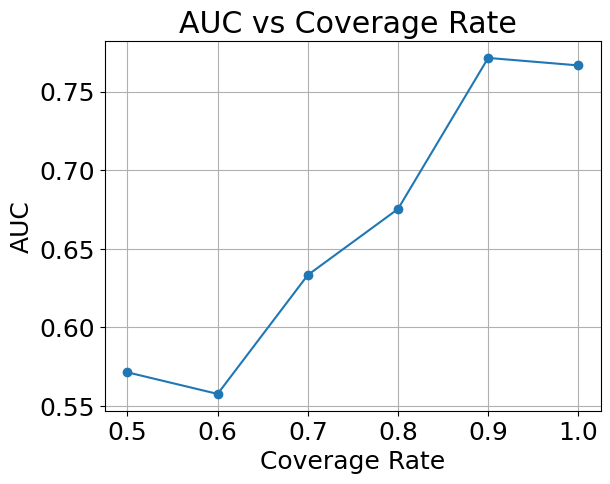

In [24]:
plot_auc_vs_coverage_fold(folder,4,70)

In [137]:
def plot_accuracy_vs_coverage_fold(folder, fold, epoch):
    
    coverage_rates = [i/10 for i in range(5, 11)]
    accuracies = []

    fold_folder = os.path.join(folder, str(fold))
    y_pred_path = os.path.join(fold_folder, 'y_pred.npy')
    y_selection_path = os.path.join(fold_folder, 'y_selection.npy')
    y_true_path = os.path.join(fold_folder, 'y_true.npy')

    y_pred = np.load(y_pred_path)
    y_selection = np.load(y_selection_path)
    y_true = np.load(y_true_path)

    for cov_rate in coverage_rates:

        output, predictions, true_labels, selection = check_correct_select(y_pred, y_selection, y_true, cov_rate, epoch)
        # 使用 accuracy_score 而不是 roc_auc_score
        accuracy = accuracy_score(true_labels, predictions)
        accuracies.append(accuracy)

    # 绘制覆盖率与准确率的关系图
    plt.plot(coverage_rates, accuracies, marker='o')
    plt.xlabel('Coverage Rate')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy vs Coverage Rate')
    plt.grid(True)
    plt.show()

## Early stopping

In [89]:
folder_lst_SENET = ['../Output/Resnet10/Cluster/SelectiveNet/SENET_c_06_Resnet10_Final_plus_5_0','../Output/Resnet10/Cluster/SelectiveNet/SENET_c_09_Resnet10_Final_plus_5_0/']
early_stopping_auc_dict = {folder:None for folder in folder_lst_SENET}


for folder in folder_lst_SENET:
    early_stopping_epochs = early_stopping_epoch(folder,30,0.005)
    early_stopping_aucs = calculate_auc_early_stopping(early_stopping_epochs)
    #early_stopping_mean_auc = calculate_auc_early_stopping_confidence(early_stopping_aucs)
    #early_stopping_auc_dict[folder] = early_stopping_mean_auc
    


In [90]:
all_aucs,all_epochs = auc_max_all_folds_epoch(folder,early_stopping_epochs)
calculate_confidence_intervals(all_aucs)

[[0.9983656 ]
 [0.99837273]
 [0.99837434]
 [0.99837494]
 [0.9983789 ]
 [0.99838495]
 [0.998386  ]
 [0.9983877 ]
 [0.9983918 ]
 [0.99839467]
 [0.99839896]
 [0.9984243 ]
 [0.9984388 ]
 [0.99848855]
 [0.99854636]]
../Output/Resnet10/Cluster/SelectiveNet/SENET_c_09_Resnet10_Final_plus_5_0/ 0 0.4
[[0.9983469 ]
 [0.99835217]
 [0.99835676]
 [0.9983602 ]
 [0.9983627 ]
 [0.9983656 ]
 [0.99837273]
 [0.99837434]
 [0.99837494]
 [0.9983789 ]
 [0.99838495]
 [0.998386  ]
 [0.9983877 ]
 [0.9983918 ]
 [0.99839467]
 [0.99839896]
 [0.9984243 ]
 [0.9984388 ]
 [0.99848855]
 [0.99854636]]
../Output/Resnet10/Cluster/SelectiveNet/SENET_c_09_Resnet10_Final_plus_5_0/ 0 0.2857142857142857
[[0.9983386 ]
 [0.9983388 ]
 [0.9983413 ]
 [0.9983419 ]
 [0.9983462 ]
 [0.9983469 ]
 [0.99835217]
 [0.99835676]
 [0.9983602 ]
 [0.9983627 ]
 [0.9983656 ]
 [0.99837273]
 [0.99837434]
 [0.99837494]
 [0.9983789 ]
 [0.99838495]
 [0.998386  ]
 [0.9983877 ]
 [0.9983918 ]
 [0.99839467]
 [0.99839896]
 [0.9984243 ]
 [0.9984388 ]
 [0.998

{0.3: (0.7098235098235098, 0.22777871850860504),
 0.4: (0.6312338751289989, 0.16621630245211821),
 0.5: (0.6227386357080799, 0.19663827395295425),
 0.6: (0.6001827077914035, 0.17547250240884588),
 0.7: (0.6483281425744479, 0.10128697257995632),
 0.8: (0.6751550790159662, 0.08470992868026019),
 0.9: (0.7020982020982022, 0.08441857339268379),
 1.0: (0.6884248251748252, 0.06964924298103846)}

Text(0.5, 1.0, 'empirical coverage over epochs')

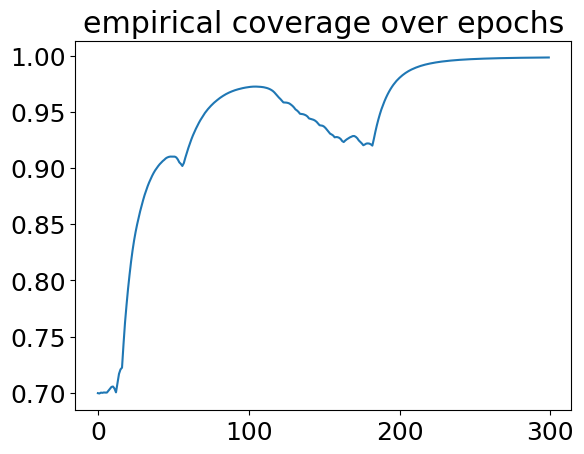

In [102]:
y_selection = np.load('../Output/Resnet10/Cluster/SelectiveNet/SENET_c_06_Resnet10_Final_plus_5_0/3/y_selection.npy')
y_sleection_mean = np.mean(y_selection, axis=1)
plt.plot(y_sleection_mean)
plt.title('empirical coverage over epochs')

    Unnamed: 0      PID   Subject Experiment  Scan       pHGP        dHGP  \
0            0  4327749  CRLM_147   CT_10043     2  32.500000   22.500000   
1            4  8205683  CRLM_283   CT_12575     2   0.000000   12.500000   
2            2  9373725  CRLM_324   CT_11784     3   0.000000   55.000000   
3            1  6818250  CRLM_234   CT_11656     4   0.000000    5.000000   
4           22  4892516  CRLM_166   CT_26366     6   0.000000    0.000000   
5            3  4033021  CRLM_141   CT_12276     9   0.000000   95.000000   
6           13  2972809  CRLM_105   CT_21529     2   5.000000   90.000000   
7            7  6190781  CRLM_207   CT_13859     2   0.000000   11.250000   
8            5  6088648  CRLM_204   CT_12927     3   0.000000  100.000000   
9           12   621065  CRLM_020   CT_20394    12   0.000000    0.000000   
10          48  3346249  CRLM_117   CT_87770     2   0.000000    0.000000   
11          37  6874007  CRLM_240   CT_32665     3   0.000000   12.500000   

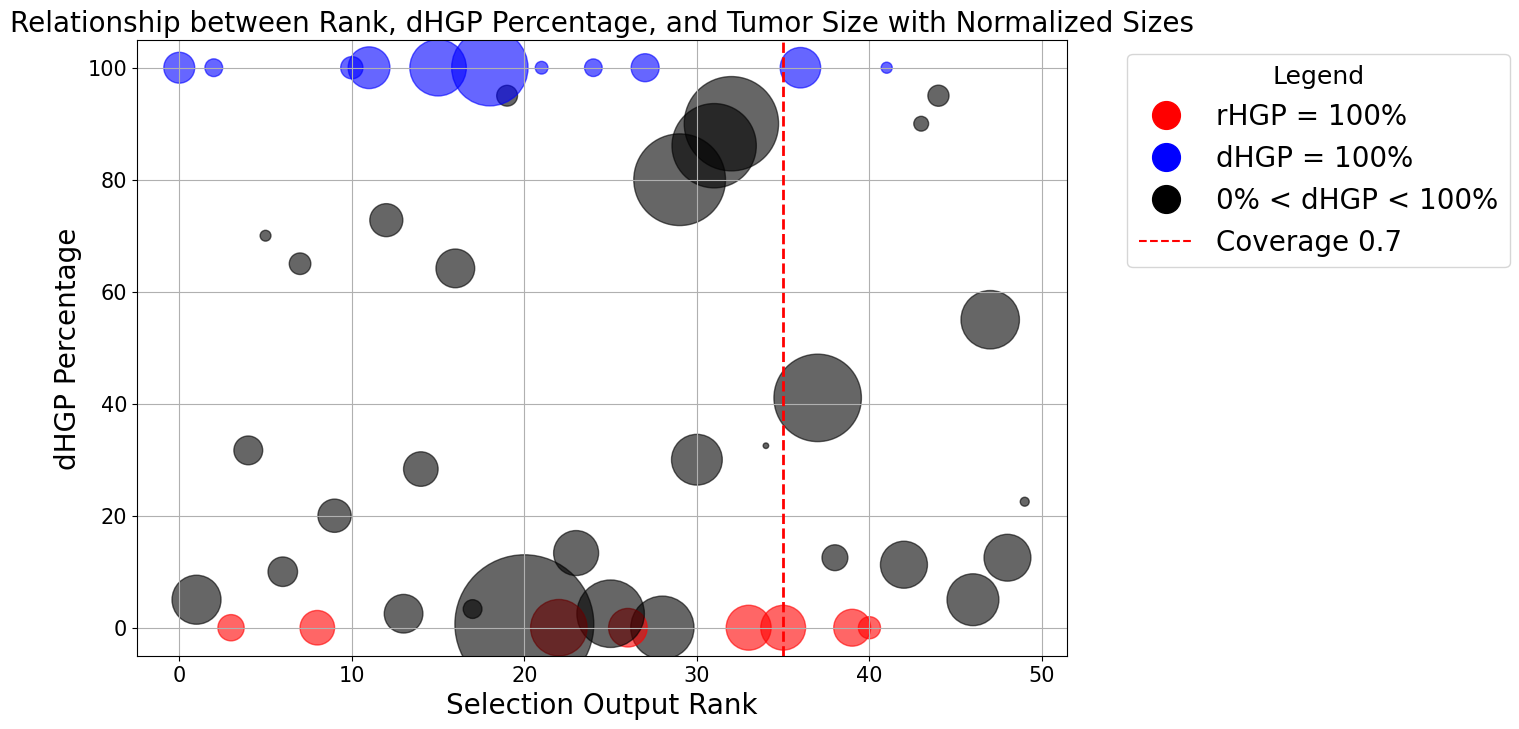

In [54]:
Selection_pattern_plot(folder,2,98)

In [159]:
model = SwinSparseTransformer(img_size=(32,256,256),in_channels=1,out_channels=1)
rand_data = torch.rand(1,1,32,256,256)
out = model(rand_data)
print(out)

0 0 0 padding
0 0 0 padding
0 0 0 padding
0 0 0 padding
tensor([[-0.1685, -0.9547]], grad_fn=<AddmmBackward0>)


# Sparse SW

